# Entraînement et évaluation des modèles de Machine Learning

## Objectif

Après les différentes étapes de préparation des données (nettoyage, normalisation et équilibrage des classes), cette phase consiste à entraîner plusieurs modèles de Machine Learning afin de détecter les différents types d'attaques présents dans le jeu de données CICIDS2017.

L'objectif est de comparer les performances de plusieurs algorithmes de classification supervisée en utilisant les mêmes données d'entraînement et le même ensemble de test.

Les modèles de mchine learning sont :

- Régression Logistique
- K-Nearest Neighbors (KNN)
- Arbre de Décision
- Random Forest
- Support Vector Machine (SVM)
- Naive Bayes

Les performances seront évaluées à l'aide des métriques suivantes :

- Accuracy
- Precision
- Recall
- F1-score
- Matrice de confusion
- Rapport de classification

## 1)Importation des bibliothèques

In [60]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2)Chargement des données

In [61]:
X_train = pd.read_csv("./data/processed/X_train_balanced.csv")
X_test = pd.read_csv("./data/processed/X_test_scaled.csv")

y_train = pd.read_csv("./data/processed/y_train_balanced.csv").squeeze()
y_test = pd.read_csv("./data/processed/y_test.csv").squeeze()

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(703347, 47)
(504473, 47)
(703347,)
(504473,)


# 1. Régression Logistique

## Présentation

La régression logistique est un algorithme de classification supervisée largement utilisé pour les problèmes de classification binaire et multiclasse. Malgré son nom, il s'agit d'un modèle de classification qui estime la probabilité d'appartenance d'une observation à une classe donnée.

Dans cette étude, la régression logistique constitue un modèle de référence permettant d'évaluer les performances des méthodes plus complexes appliquées au jeu de données CICIDS2017.

### Importation de l'algorithme

In [62]:
from sklearn.linear_model import LogisticRegression

### Initialisation du modèle

Le modèle est configuré avec un nombre maximal de 1000 itérations afin d'assurer la convergence de l'algorithme lors de l'apprentissage.

In [63]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

### Entraînement du modèle

Le modèle est entraîné à partir de l'ensemble d'entraînement préparé lors des étapes précédentes.

In [64]:
log_reg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### Prédiction

Une fois l'entraînement terminé, le modèle est utilisé pour prédire les classes des observations de l'ensemble de test.

In [65]:
y_pred = log_reg.predict(X_test)

### Évaluation des performances

Les performances du modèle sont évaluées à l'aide des métriques suivantes :

- Accuracy
- Precision
- Recall
- F1-score

Ces indicateurs permettent d'évaluer la capacité du modèle à classifier correctement les différents types de trafic réseau.

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

Accuracy  : 0.9523
Precision : 0.9692
Recall    : 0.9523
F1-score  : 0.9582


### Rapport de classification

Le rapport de classification présente les performances du modèle pour chaque classe en termes de précision, de rappel et de F1-score.

In [67]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    419297
           1       0.14      0.37      0.21       391
           2       0.94      1.00      0.97     25603
           3       0.82      0.86      0.84      2057
           4       0.84      1.00      0.91     34570
           5       0.67      0.85      0.75      1046
           6       0.76      0.91      0.83      1077
           7       0.46      0.99      0.63      1187
           8       0.67      1.00      0.80         2
           9       0.03      0.86      0.06         7
          10       0.71      1.00      0.83     18164
          11       0.49      0.91      0.64       644
          12       0.07      0.87      0.14       294
          13       0.00      0.25      0.00         4
          14       0.04      0.01      0.01       130

    accuracy                           0.95    504473
   macro avg       0.51      0.79      0.57    504473
weighted avg       0.97   

### Matrice de confusion

La matrice de confusion permet de visualiser les prédictions correctes ainsi que les erreurs de classification entre les différentes catégories d'attaques.

<Figure size 1200x1000 with 0 Axes>

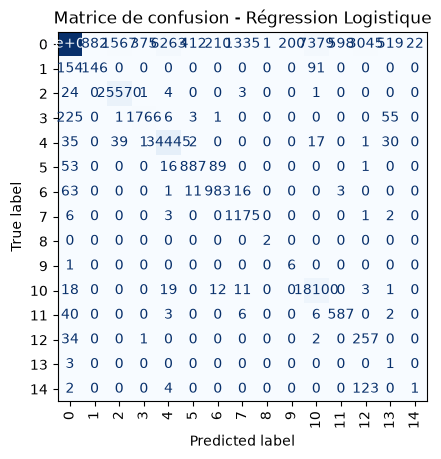

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    xticks_rotation=90,
    colorbar=False
)

plt.title("Matrice de confusion - Régression Logistique")

plt.show()

### Enregistrement des métrique de Logistic Regression

In [69]:
import importlib
import utils

importlib.reload(utils)

from utils import save_results

In [70]:
from utils import save_results

save_results(
    model_name="Logistic Regression",
    accuracy=accuracy,
    precision=precision,
    recall=recall,
    f1_score=f1,
    train_time=training_time,
    prediction_time=prediction_time
)

Logistic Regression enregistré avec succès.


# Sauvegarde du modèle logistic regrression entraînés

## Objectif

Après l'entraînement et l'évaluation des différents modèles de Machine Learning et de Deep Learning, il est nécessaire de les sauvegarder afin de pouvoir les réutiliser ultérieurement sans effectuer un nouvel entraînement.

Cette étape est essentielle dans un pipeline MLOps puisqu'elle permet de déployer directement le modèle retenu dans une application ou une API de prédiction.

In [90]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(log_reg, "models/Logistic Regression.pkl")

print("Logistic Regression sauvegardé.")

Logistic Regression sauvegardé.


# 2. Arbre de Décision (Decision Tree)

## Présentation

L'arbre de décision (*Decision Tree*) est un algorithme de classification supervisée qui construit une structure arborescente composée de nœuds de décision et de feuilles représentant les classes prédites.

À chaque nœud, l'algorithme sélectionne la variable qui permet de séparer au mieux les observations selon un critère d'impureté, tel que l'indice de Gini ou l'entropie. Cette approche permet de modéliser des relations non linéaires entre les variables.

Dans cette étude, l'arbre de décision est utilisé afin d'évaluer sa capacité à classifier les différents types de trafic réseau du jeu de données CICIDS2017.

## Importation de l'algorithme

In [71]:
from sklearn.tree import DecisionTreeClassifier

## Initialisation du modèle

Le modèle est initialisé en utilisant le critère **Gini** pour mesurer l'impureté des nœuds et une graine aléatoire fixée afin d'assurer la reproductibilité des résultats.

In [72]:
decision_tree = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

## Entraînement du modèle

Le modèle est entraîné sur l'ensemble d'entraînement équilibré obtenu lors de la phase de préparation des données.

In [73]:
import time

start = time.time()

decision_tree.fit(X_train, y_train)

training_time = time.time() - start

print(f"Temps d'entraînement : {training_time:.2f} secondes")

Temps d'entraînement : 28.17 secondes


## Prédiction

Le modèle entraîné est ensuite utilisé pour prédire les classes des observations de l'ensemble de test.

In [74]:
y_pred = decision_tree.predict(X_test)

## Évaluation des performances

Les performances du modèle sont évaluées à l'aide des métriques suivantes :

- Accuracy
- Precision
- Recall
- F1-score

Les métriques sont calculées selon une moyenne pondérée (*weighted average*) afin de tenir compte du caractère multiclasse du problème.

In [75]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

Accuracy  : 0.9982
Precision : 0.9983
Recall    : 0.9982
F1-score  : 0.9982


## Rapport de classification

Le rapport de classification présente les performances du modèle pour chaque classe en termes de précision, de rappel et de F1-score.

In [76]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419297
           1       0.69      0.95      0.80       391
           2       1.00      1.00      1.00     25603
           3       0.99      0.99      0.99      2057
           4       1.00      1.00      1.00     34570
           5       0.97      0.99      0.98      1046
           6       0.96      0.99      0.98      1077
           7       1.00      1.00      1.00      1187
           8       1.00      0.50      0.67         2
           9       0.50      0.71      0.59         7
          10       0.99      1.00      0.99     18164
          11       0.99      1.00      1.00       644
          12       0.72      0.67      0.69       294
          13       0.50      0.75      0.60         4
          14       0.41      0.56      0.47       130

    accuracy                           1.00    504473
   macro avg       0.85      0.87      0.85    504473
weighted avg       1.00   

## Matrice de confusion

La matrice de confusion permet de visualiser les prédictions correctes ainsi que les erreurs de classification entre les différentes catégories de trafic réseau.

<Figure size 1200x1000 with 0 Axes>

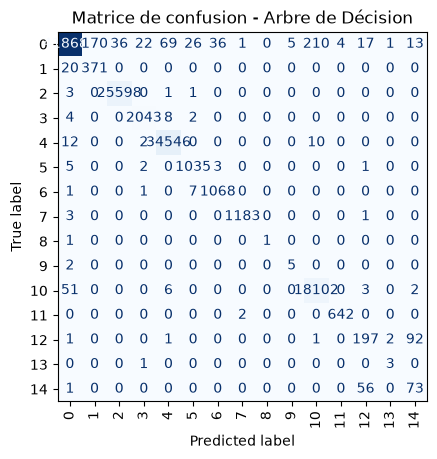

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    xticks_rotation=90,
    colorbar=False
)

plt.title("Matrice de confusion - Arbre de Décision")

plt.show()

### enregistrement des métriques Decision Tree

In [78]:
import importlib
import utils

importlib.reload(utils)

from utils import save_results

In [79]:
from utils import save_results

save_results(
    model_name="Decision Tree",
    accuracy=accuracy,
    precision=precision,
    recall=recall,
    f1_score=f1,
    train_time=training_time,
    prediction_time=prediction_time
)

Decision Tree enregistré avec succès.


# Sauvegarde du modèle Decision Tree entraînés

## Objectif

Après l'entraînement et l'évaluation des différents modèles de Machine Learning et de Deep Learning, il est nécessaire de les sauvegarder afin de pouvoir les réutiliser ultérieurement sans effectuer un nouvel entraînement.

Cette étape est essentielle dans un pipeline MLOps puisqu'elle permet de déployer directement le modèle retenu dans une application ou une API de prédiction.

In [93]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    decision_tree,
    "models/Decision Tree.pkl"
)

print("Decision Tree sauvegardé avec succès.")

Decision Tree sauvegardé avec succès.


# 3. Random Forest

## Présentation

Le **Random Forest** est un algorithme d'apprentissage supervisé basé sur un ensemble d'arbres de décision (*ensemble learning*).

Contrairement à un arbre de décision unique, le Random Forest construit plusieurs arbres à partir de différents sous-ensembles des données et des variables. La prédiction finale est obtenue par un vote majoritaire des différents arbres.

Cette approche permet de réduire le risque de surapprentissage (*overfitting*), d'améliorer la capacité de généralisation du modèle et d'obtenir de meilleures performances sur des jeux de données complexes tels que CICIDS2017.

Dans cette étude, le Random Forest est utilisé afin d'évaluer sa capacité à détecter les différents types d'attaques réseau et à comparer ses performances avec celles des autres modèles de Machine Learning et de Deep Learning.

## Importation de l'algorithme

In [80]:
from sklearn.ensemble import RandomForestClassifier

## Initialisation du modèle

Le modèle est initialisé avec **100 arbres de décision** (`n_estimators=100`). Cette valeur constitue un bon compromis entre les performances et le temps d'entraînement.

Une graine aléatoire est fixée afin de garantir la reproductibilité des résultats.

In [81]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

## Entraînement du modèle

Le modèle est entraîné sur l'ensemble d'entraînement équilibré afin d'apprendre les caractéristiques des différentes classes du jeu de données CICIDS2017.

In [82]:
import time

start = time.time()

random_forest.fit(X_train, y_train)

training_time = time.time() - start

print(f"Temps d'entraînement : {training_time:.2f} secondes")

Temps d'entraînement : 83.53 secondes


## Prédiction

Le modèle entraîné est utilisé pour prédire les classes des observations de l'ensemble de test.

In [83]:
start = time.time()

y_pred = random_forest.predict(X_test)

prediction_time = time.time() - start

print(f"Temps de prédiction : {prediction_time:.2f} secondes")

Temps de prédiction : 4.55 secondes


## Évaluation des performances

Les performances du modèle sont évaluées à l'aide des métriques suivantes :

- Accuracy
- Precision
- Recall
- F1-score

Les métriques sont calculées selon une moyenne pondérée (*weighted average*) afin de tenir compte de la distribution des différentes classes.

In [84]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1-score        : {f1:.4f}")
print(f"Temps entraînement : {training_time:.2f} s")
print(f"Temps prédiction   : {prediction_time:.2f} s")

Accuracy        : 0.9986
Precision       : 0.9987
Recall          : 0.9986
F1-score        : 0.9986
Temps entraînement : 83.53 s
Temps prédiction   : 4.55 s


## Rapport de classification

Le rapport de classification présente les performances du modèle pour chacune des classes du jeu de données en termes de précision, de rappel et de F1-score.

In [85]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419297
           1       0.69      0.99      0.81       391
           2       1.00      1.00      1.00     25603
           3       1.00      0.99      0.99      2057
           4       1.00      1.00      1.00     34570
           5       0.99      0.99      0.99      1046
           6       0.99      1.00      0.99      1077
           7       1.00      1.00      1.00      1187
           8       1.00      1.00      1.00         2
           9       1.00      0.71      0.83         7
          10       0.99      1.00      0.99     18164
          11       1.00      1.00      1.00       644
          12       0.72      0.92      0.81       294
          13       1.00      1.00      1.00         4
          14       0.49      0.19      0.28       130

    accuracy                           1.00    504473
   macro avg       0.92      0.92      0.91    504473
weighted avg       1.00   

## Matrice de confusion

La matrice de confusion permet de visualiser les classes correctement prédites ainsi que les erreurs de classification entre les différents types de trafic réseau.

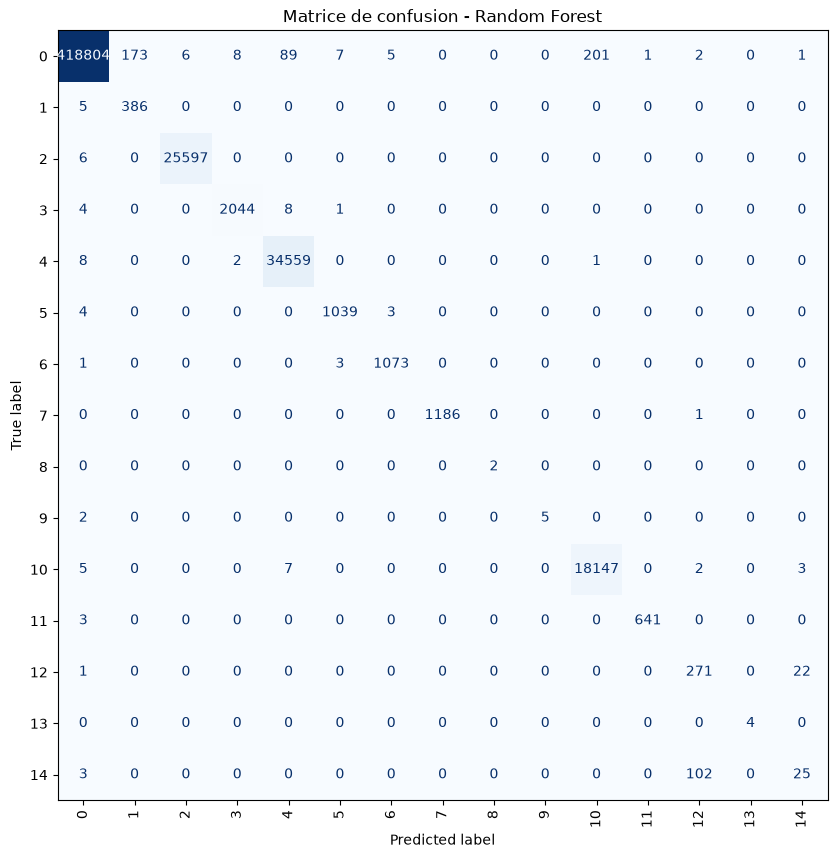

In [86]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    xticks_rotation=90,
    colorbar=False,
    ax=ax
)

plt.title("Matrice de confusion - Random Forest")
plt.show()

### enregistrement des métriques Random Forest

In [87]:
from utils import save_results

save_results(
    model_name="Random Forest",
    accuracy=accuracy,
    precision=precision,
    recall=recall,
    f1_score=f1,
    train_time=training_time,
    prediction_time=prediction_time
)

Random Forest enregistré avec succès.


# Sauvegarde du modèle Random forest entraînés

## Objectif

Après l'entraînement et l'évaluation des différents modèles de Machine Learning et de Deep Learning, il est nécessaire de les sauvegarder afin de pouvoir les réutiliser ultérieurement sans effectuer un nouvel entraînement.

Cette étape est essentielle dans un pipeline MLOps puisqu'elle permet de déployer directement le modèle retenu dans une application ou une API de prédiction.

In [96]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    random_forest,
    "models/Random Forest.pkl"
)

print("Random Forest sauvegardé avec succès.")

Random Forest sauvegardé avec succès.
